large chi ^2 score means larger difference between distrubution meaning that the p value is small and that the features have a affect meaning that we reject the null hypothesis that the features are independent to the outcome

-ch square requires you to fill all null fields .fillna()

in class exercise

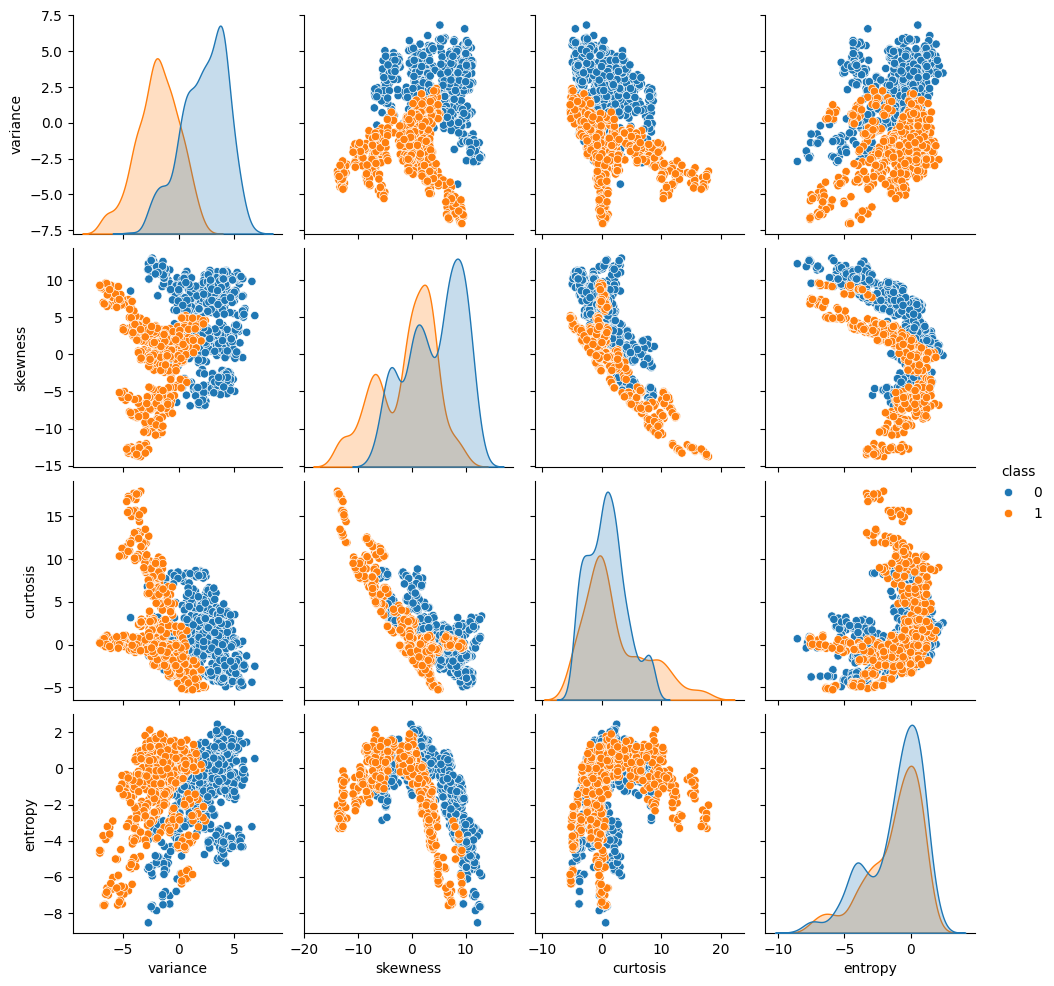

In [12]:
import numpy as np
from sklearn import svm
from sklearn.svm import LinearSVC
from sklearn import metrics
from sklearn.datasets import make_moons, load_iris
from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score, KFold
import pandas as pd
import seaborn as sns

features = ['variance','skewness','curtosis','entropy','class']
moneyData = pd.read_csv("data_banknote_authentication.txt")
moneyData.head()
moneyData.columns = features


sns.pairplot(moneyData, hue='class')



Feature Selection
Use the sklearn feature_selection SelectPercentile function using the f_classif statistic to quantify which features are likely to be best for use with classification

In [ ]:
from sklearn import metrics
from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score, KFold

from sklearn import tree

from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import KNeighborsClassifier

from sklearn.feature_selection import SelectKBest, SelectPercentile
from sklearn.feature_selection import chi2, f_classif

from sklearn import svm
from sklearn.linear_model import LogisticRegression

# XTrain,XTest,YTrain,YTest= train_test_split
features = moneyData.columns[0:2]

predictor_features = moneyData.columns[:-1]
selector = SelectPercentile(f_classif) # f_classif - anovva? #used chi squared before chi^2
X_new = selector.fit_transform(moneyData[predictor_features].values, moneyData["class"].values)
                                #xtrain , ytrain?
print(predictor_features)
print("P Values:", selector.pvalues_)
for pr in zip(predictor_features, selector.pvalues_):
    print(pr[0], pr[1])

Index(['variance', 'skewness', 'curtosis', 'entropy'], dtype='object')
P Values: [1.23502427e-223 2.08732031e-067 7.38738596e-009 3.90691758e-001]
variance 1.23502427309135e-223
skewness 2.0873203147540908e-67
curtosis 7.3873859568100605e-09
entropy 0.3906917582271001


In [17]:
lr = LogisticRegression()
lrScores = cross_val_score(estimator = lr, X = moneyData[features].values, y = moneyData["class"].values)
print(lrScores)

[0.88363636 0.8649635  0.87226277 0.90875912 0.88686131]
